In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

### Sistema de 2 graus de liberdade excitado por uma força harmônica no 1° grau de liberdade

In [29]:
m1 = 10.0   #kg
m2 = 10.0   #kg
k1 = 2000.0   #N/m
k2 = 10000.0   #N/m
k3 = 2000.0   #N/m

In [33]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1 = 10.0   #N
w = 30.0   #Hz
F = np.array([F1,0.0]) 

M = np.array([[m1,0.0],[0.0,m2]])
K = np.array([[k1+k3,-k3],[-k3,k2+k3]])

# assumindo uma solucao Q = [Q1,Q2]*e^(iwt)

# matriz dinamica
M_inv = np.linalg.inv(M)
D = M_inv@K

print('Matriz dinâmica')
print(D)

# modos de vibração e frequências naturais
autovalores, autovetores = np.linalg.eig(D)

f_naturais = autovalores**0.5
modos = autovetores

print('\nFrequências naturais e modos de vibração')
print(f_naturais)
print(modos)

# matriz de massa modal e matriz de rigidez modal
modos_T = np.transpose(modos)

M_modal = modos@M@modos_T
K_modal = modos@K@modos_T

print('\nMassa modal')
print(M_modal)

print('\nRigidez modal')
print(K_modal)

# receptancia
Z = -w**2.0*M + K
R = np.linalg.inv(Z)

print('\nReceptância')
print(R)

# amplitude de resposta
Q = R@F

print('\nAmplitude de resposta')
print(Q)

Matriz dinâmica
[[ 400. -200.]
 [-200. 1200.]]

Frequências naturais e modos de vibração
[18.7826091  35.31591136]
[[-0.97324899  0.22975292]
 [-0.22975292 -0.97324899]]

Massa modal
[[10.  0.]
 [ 0. 10.]]

Rigidez modal
[[ 5316.718427 -3577.708764]
 [-3577.708764 10683.281573]]

Receptância
[[-0.00015789 -0.00010526]
 [-0.00010526  0.00026316]]

Amplitude de resposta
[-0.00157895 -0.00105263]


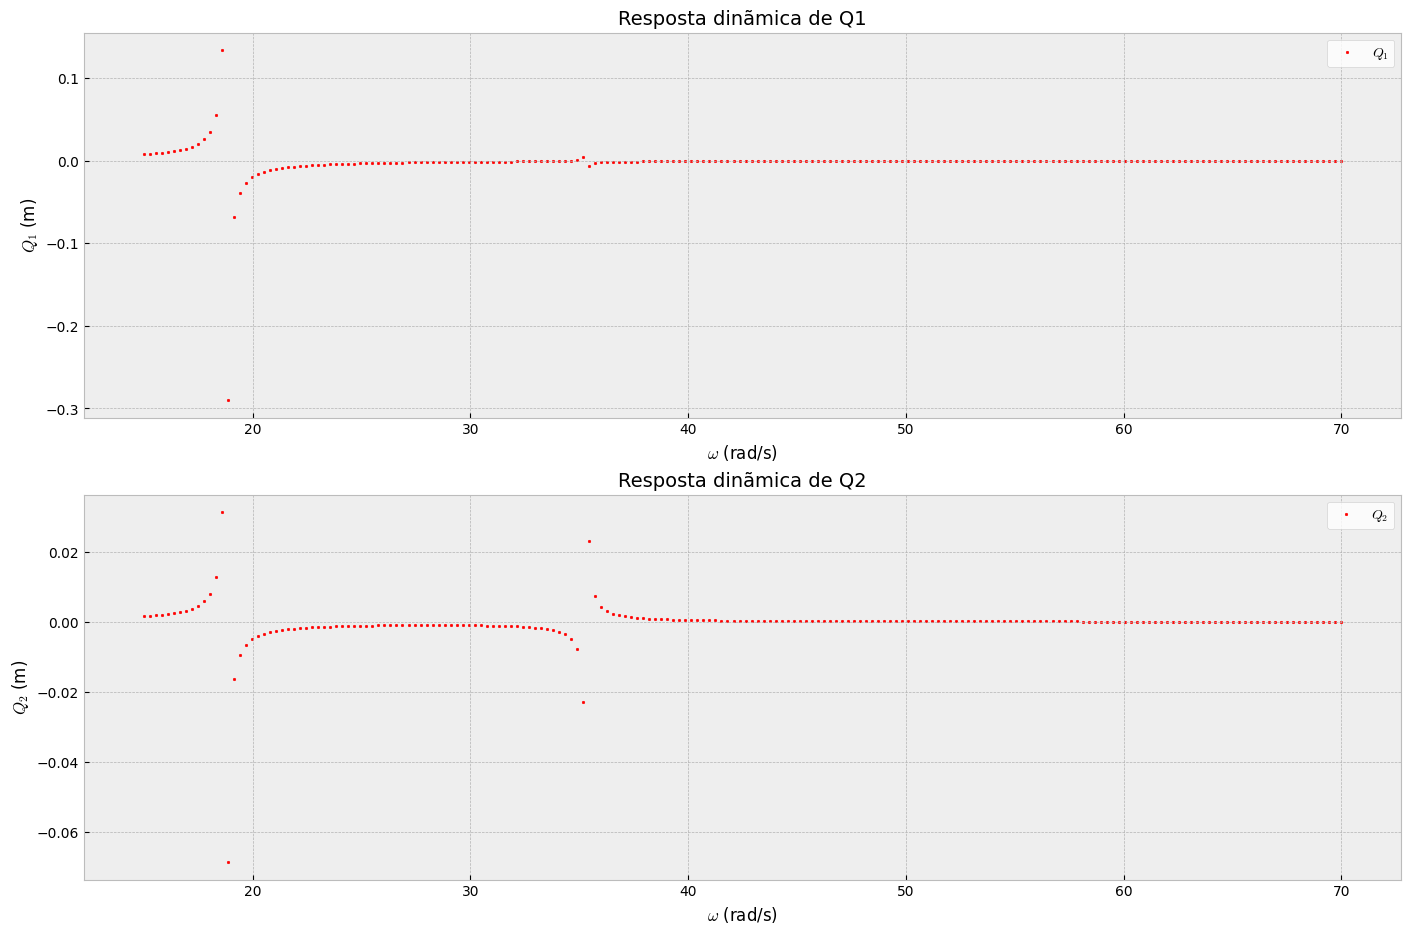

In [32]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1 = 10.0
w = np.linspace(15.0,70.0,200)
F = np.array([F1,0.0]) 

M = np.array([[m1,0.0],[0.0,m2]])
K = np.array([[k1+k3,-k3],[-k3,k2+k3]])

def R_din(w,M,K,F):
    Q_list = np.empty([len(w),2])
    for i in range(len(w)):
        Z = -w[i]**2.0*M + K
        R = np.linalg.inv(Z)

        Q = R@F
        Q_list[i] = Q

    return Q_list

Q_din = R_din(w,M,K,F)


plt.style.use('bmh')

fig1, ((ax1), (ax2)) = plt.subplots(2, sharey=False, sharex=False, figsize = (17,11))

#ax1.plot(w,Q_din[:,0], color='red', linewidth=1.0, label=r'$Q_1$')
ax1.scatter(w,Q_din[:,0], color='red', s=3.0, label=r'$Q_1$')
ax1.set_title('Resposta dinãmica de Q1',fontdict={'fontsize':14})
ax1.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax1.set_ylabel('$Q_1$ (m)',fontdict={'fontsize':12})
ax1.legend(loc='best',facecolor ='w')

#ax2.plot(w,Q_din[:,1], color='red', linewidth=1.0, label=r'$Q_2$')
ax2.scatter(w,Q_din[:,1], color='red', s=3.0, label=r'$Q_2$')
ax2.set_title('Resposta dinãmica de Q2',fontdict={'fontsize':14})
ax2.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax2.set_ylabel('$Q_2$ (m)',fontdict={'fontsize':12})
ax2.legend(loc='best',facecolor ='w')

plt.show()

### Edifício de 2 andares sujeito a deslocamento forçado em sua base